<a href="https://colab.research.google.com/github/Chanhui03/2026_1_deeplearning/blob/main/9%EC%A3%BC%EC%B0%A8_20221334_%EA%B6%8C%EC%B0%AC%ED%9D%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#[Step 1] 데이터 로드 및 전처리

In [ ]:
# mnist 데이터 불러오기
from tensorflow.keras.datasets import fashion_mnist
# 카테고리화하기
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 이미지 표시하기
import matplotlib.pyplot as plt

import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 전처리
# 0~1 사이의 값으로 바꾸기 위해 255로 바꿈
X_train = X_train.reshape(60000, 28*28).astype('float32') / 255.0
X_test = X_test.reshape(10000, 28*28).astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

#[Step 2] 베이스라인 모델 실행

In [ ]:
# 베이스라인 모델
model = Sequential()

model.add(Dense(512, input_dim = 28*28, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8099 - loss: 0.5489 - val_accuracy: 0.8478 - val_loss: 0.4274
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8609 - loss: 0.3969 - val_accuracy: 0.8631 - val_loss: 0.3783
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8725 - loss: 0.3570 - val_accuracy: 0.8747 - val_loss: 0.3575
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8821 - loss: 0.3235 - val_accuracy: 0.8565 - val_loss: 0.3914
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8904 - loss: 0.3031 - val_accuracy: 0.8764 - val_loss: 0.3443
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8960 - loss: 0.2864 - val_accuracy: 0.8787 - val_loss: 0.3390
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9011 - loss: 0.2702 - val_accuracy: 0.8857 - val_loss: 0.3167
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9040 - loss: 0.2587 - val_accu

#[Step 3] 모델 구조 변경 실험

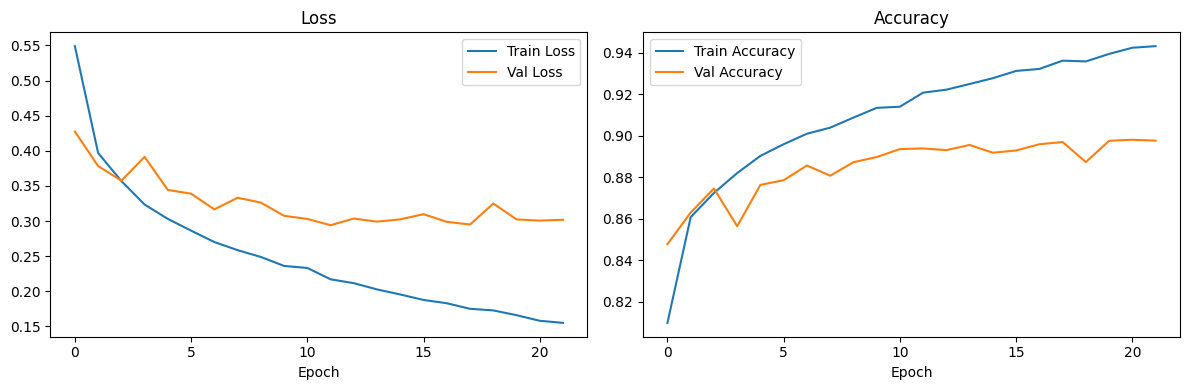

In [ ]:
# 베이스라인 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8822 - loss: 0.3251


[0.325076699256897, 0.8822000026702881]

In [ ]:
# 구조 변경 첫번째
# 노드 수 변경
# (512->10) -> (256->10)
model_1 = Sequential()

model_1.add(Dense(256, input_dim = 28*28, activation='relu'))
model_1.add(Dense(10, activation='softmax'))

model_1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7958 - loss: 0.5916 - val_accuracy: 0.8304 - val_loss: 0.4791
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8539 - loss: 0.4184 - val_accuracy: 0.8598 - val_loss: 0.3989
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8696 - loss: 0.3687 - val_accuracy: 0.8643 - val_loss: 0.3772
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8758 - loss: 0.3434 - val_accuracy: 0.8758 - val_loss: 0.3548
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8852 - loss: 0.3194 - val_accuracy: 0.8781 - val_loss: 0.3378
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8896 - loss: 0.3020 - val_accuracy: 0.8782 - val_loss: 0.3371
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8971 - loss: 0.2854 - val_accuracy: 0.8825 - val_loss: 0.3305
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8975 - loss: 0.2789 - val_accuracy: 0

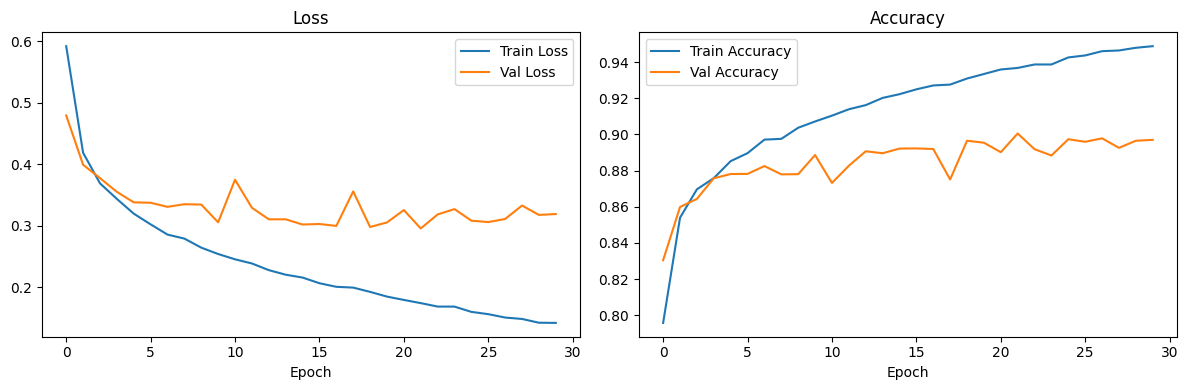

In [ ]:
# 첫번째 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_1.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.3318


[0.33177271485328674, 0.8906000256538391]

In [ ]:
# 구조 변경 두번째
# 노드 수 변경
# (512->10) -> (1024->10)
model_2 = Sequential()

model_2.add(Dense(1024, input_dim = 28*28, activation='relu'))
model_2.add(Dense(10, activation='softmax'))

model_2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8167 - loss: 0.5267 - val_accuracy: 0.8530 - val_loss: 0.4085
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8624 - loss: 0.3879 - val_accuracy: 0.8703 - val_loss: 0.3704
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8759 - loss: 0.3409 - val_accuracy: 0.8688 - val_loss: 0.3602
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.8869 - loss: 0.3098 - val_accuracy: 0.8743 - val_loss: 0.3520
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8915 - loss: 0.2959 - val_accuracy: 0.8818 - val_loss: 0.3291
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8981 - loss: 0.2791 - val_accuracy: 0.8867 - val_loss: 0.3104
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9023 - loss: 0.2612 - val_accuracy: 0.8827 - val_loss: 0.3207
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9085 - loss: 0.2477 - val_acc

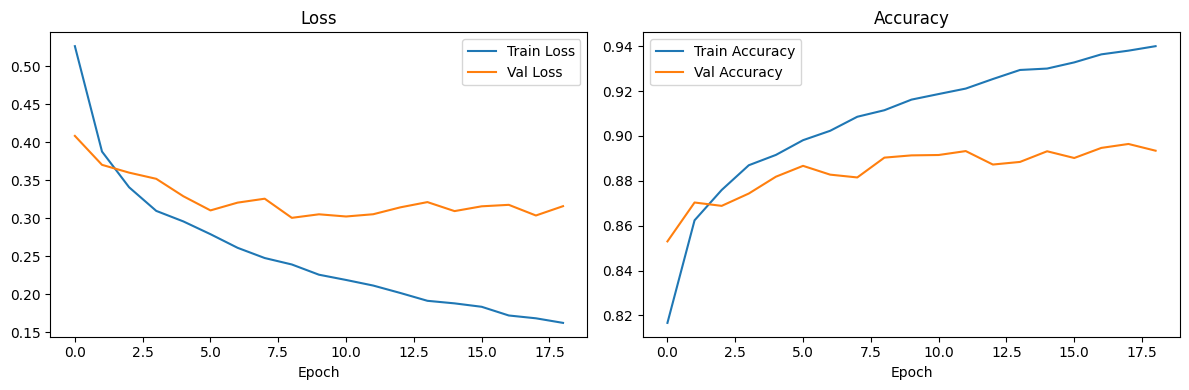

In [ ]:
# 두번째 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_2.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3252


[0.32524704933166504, 0.8853999972343445]

In [ ]:
# 구조 변경 세번째
# 층 수 변경
# (512->10) -> (512->256->10)
model_3 = Sequential()

model_3.add(Dense(512, input_dim = 28*28, activation='relu'))
model_3.add(Dense(256, activation='relu'))
model_3.add(Dense(10, activation='softmax'))

model_3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8115 - loss: 0.5306 - val_accuracy: 0.8497 - val_loss: 0.4105
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8631 - loss: 0.3764 - val_accuracy: 0.8721 - val_loss: 0.3583
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8799 - loss: 0.3278 - val_accuracy: 0.8687 - val_loss: 0.3710
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8875 - loss: 0.3043 - val_accuracy: 0.8823 - val_loss: 0.3262
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8945 - loss: 0.2839 - val_accuracy: 0.8787 - val_loss: 0.3384
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8995 - loss: 0.2704 - val_accuracy: 0.8844 - val_loss: 0.3180
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9047 - loss: 0.2537 - val_accuracy: 0.8870 - val_loss: 0.3194
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9090 - loss: 0.2424 - val_accu

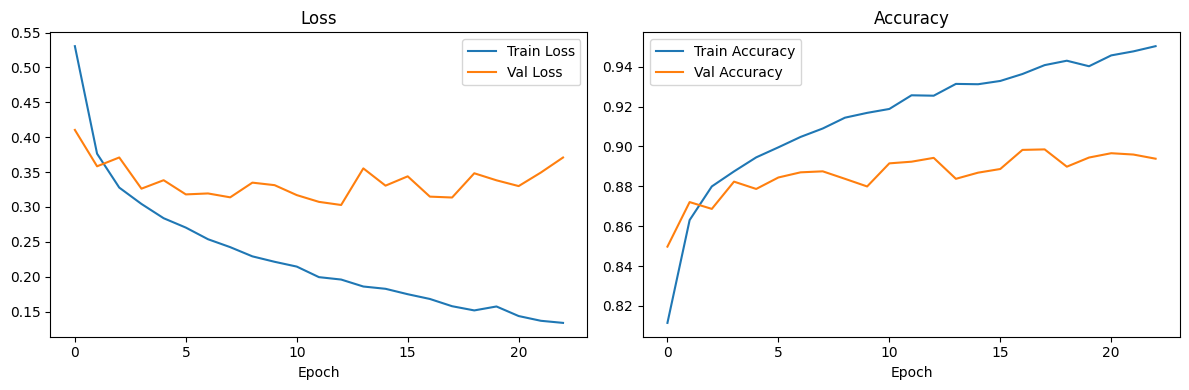

In [ ]:
# 세번째 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_3.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8901 - loss: 0.3297


[0.3297370970249176, 0.8901000022888184]

In [ ]:
# 구조 변경 네번째
# 활성화 함수 변경
# relu -> tanh
model_4 = Sequential()

model_4.add(Dense(512, input_dim = 28*28, activation='tanh'))
model_4.add(Dense(10, activation='softmax'))

model_4.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history_4 = model_4.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8092 - loss: 0.5372 - val_accuracy: 0.8478 - val_loss: 0.4267
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8549 - loss: 0.4074 - val_accuracy: 0.8552 - val_loss: 0.4006
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8646 - loss: 0.3762 - val_accuracy: 0.8658 - val_loss: 0.3661
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8745 - loss: 0.3462 - val_accuracy: 0.8742 - val_loss: 0.3507
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8776 - loss: 0.3337 - val_accuracy: 0.8679 - val_loss: 0.3635
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8851 - loss: 0.3150 - val_accuracy: 0.8776 - val_loss: 0.3367
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8895 - loss: 0.2993 - val_accuracy: 0.8803 - val_loss: 0.3280
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8940 - loss: 0.2873 - val_accu

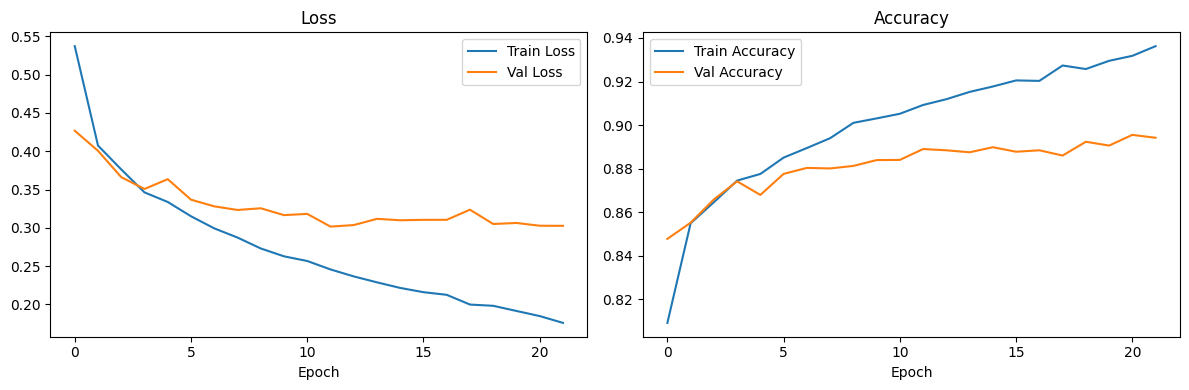

In [ ]:
# 네번째 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_4.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.3304


[0.33035358786582947, 0.8816999793052673]

In [ ]:
# 구조 변경 다섯번째
# 활성화 함수 변경
# relu -> sigmoid
model_5 = Sequential()

model_5.add(Dense(512, input_dim = 28*28, activation='sigmoid'))
model_5.add(Dense(10, activation='softmax'))

model_5.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

history_5 = model_5.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=200,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7749 - loss: 0.6758 - val_accuracy: 0.8286 - val_loss: 0.4875
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8398 - loss: 0.4558 - val_accuracy: 0.8393 - val_loss: 0.4439
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8542 - loss: 0.4144 - val_accuracy: 0.8530 - val_loss: 0.4120
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8612 - loss: 0.3911 - val_accuracy: 0.8596 - val_loss: 0.3929
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8676 - loss: 0.3700 - val_accuracy: 0.8658 - val_loss: 0.3759
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8731 - loss: 0.3564 - val_accuracy: 0.8682 - val_loss: 0.3707
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8747 - loss: 0.3482 - val_accuracy: 0.8727 - val_loss: 0.3528
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8794 - loss: 0.3319 - val_accu

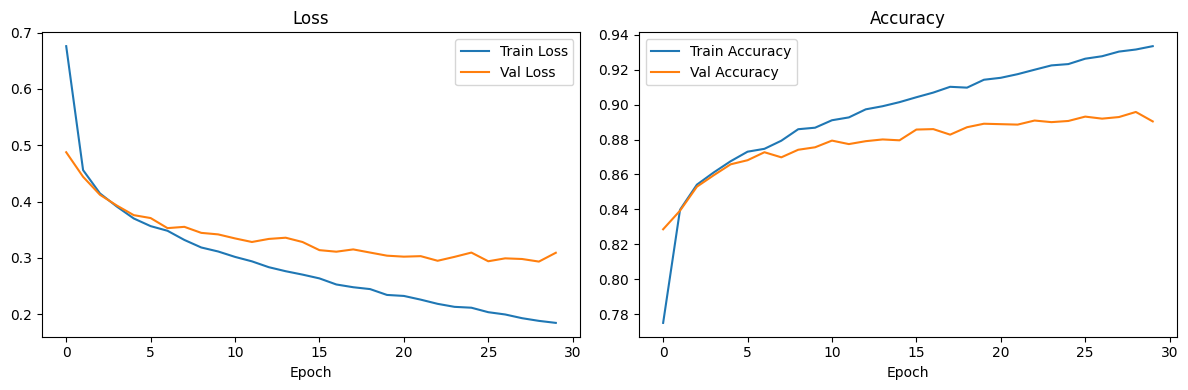

In [ ]:
# 다섯번째 모델 학습 곡선
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_5.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_5.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8847 - loss: 0.3289


[0.3288640081882477, 0.8847000002861023]

#[Step 4] 최적 모델 선정 및 근거 서술


테스트셋 정확도 측면에서는 노드 수를 512에서 256으로 줄인 첫 번째 모델(model_1)이 0.8906으로 가장 높은 성능을 보였습니다. 이는 노드 수를 늘린 두 번째 모델(model_2, 1024노드)과 비교했을 때 오히려 노드 수를 줄이는 것이 Fashion MNIST 데이터셋에서는 더 효과적임을 나타냅니다. 과도한 파라미터는 학습 데이터에 지나치게 맞춰지는 과적합을 유발할 수 있으므로, 적절히 축소된 모델이 일반화 성능에서 유리함을 실험을 통해 확인할 수 있었습니다.

과적합 방지 측면에서는 활성화 함수로 sigmoid를 사용한 다섯 번째 모델(model_5)의 학습 곡선에서 훈련셋과 검증셋 간의 loss 격차가 가장 작게 나타났습니다. relu나 tanh를 사용한 모델들은 에포크가 진행될수록 훈련 정확도와 검증 정확도 사이의 간격이 벌어지는 경향이 있었던 반면, sigmoid는 상대적으로 안정적인 학습 곡선을 보여주었습니다.

따라서 두 실험 결과를 종합하여, 노드 구성은 Dense(256) → Dense(10)을 유지하고 은닉층의 활성화 함수는 relu 대신 sigmoid로 변경한 모델을 최적 모델로 제안합니다. 층 수는 베이스라인과 동일하게 2층으로 유지하며, 이 조합이 테스트 정확도와 과적합 방지 두 가지 기준을 동시에 만족하는 최선의 구조라고 판단됩니다.